In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from math import e
from scipy.optimize import minimize
from IPython.display import clear_output
from scipy import optimize
from scipy.stats import norm
import pickle
from scipy import integrate
from scipy import stats

In [2]:
data = pd.read_excel('data.ods')

In [3]:
data['T (ºC)'] = data['T_R_K'] - 273

In [4]:
data = data.loc[(data['CINÉTICA'] == 1) | (data['DESATIVAÇÃO'] == 1)]
# data = data.loc[((data['F_C2H6_s_mol_s'] != 0) & (data['F_C3H8_s_mol_s'] != 0))]

In [5]:
data = data.copy()

In [6]:
data[['F_Olef_C2_e', 'F_Olef_C3_e', 
    'F_Olef_C9_e', 'F_Olef_C10_e', 'F_Olef_C11_e', 
   'F_Olef_C12_e', 'F_Olef_C13_e', 'F_Olef_C14_e', 'F_Olef_C15_e', 
     'F_Olef_C16_e', 'F_Olef_C17_e', 'F_Olef_C18_e',

    
    'F_C1_e', 'F_C2_e', 'F_C3_e', 'F_C9_e', 'F_C10_e', 'F_C11_e', 
      'F_C12_e', 'F_C13_e', 'F_C14_e', 'F_C15_e', 'F_C16_e', 'F_C17_e', 'F_C18_e',
      'F_C19_e', 'F_C20_e', 'F_C21_e', 'F_C22_e', 'F_C23_e', 'F_C24_e', 'F_C25_e', 
      'F_C26_e', 'F_C27_e', 'F_C28_e', 'F_C29_e', 'F_C30_e', 'F_C31_e', 'F_C32_e', 
      'F_C33_e', 'F_C34_e', 'F_C35_e', 'F_C36_e']] = 0

In [7]:
# doing raw mass balance to check errors

In [8]:
data['$m_{gas,in}$ (g/s)'] = data['F_H2_e_mol_s']*2 + data['F_CO_e_mol_s']*(12+16)

In [9]:
data['$m_{gas,out}$ (g/s)'] = (data['F_H2_s_mol_s']*2 + data['F_CO_s_mol_s']*(12+16)
                              + data['F_CO2_s_mol_s']*44 + data['F_CH4_s_mol_s']*16
                              + data['F_C2H6_s_mol_s']*((2*12)+6) + data['F_C3H8_s_mol_s']*((3*12)+8)
                              )

In [10]:
data['$m_{liq,out}$ (g/s)'] = data['$m_{gas,in}$ (g/s)'] - data['$m_{gas,out}$ (g/s)']

In [11]:
data['$m_{in}$ (g/s)'] = data['$m_{gas,in}$ (g/s)']

In [12]:
data['t_s'] = data['t_h']*3600

In [13]:
data['$m_{in,cumul}$ (g)'] = integrate.cumulative_trapezoid(data['$m_{gas,in}$ (g/s)'], data['t_s'], initial = 0)

In [14]:
edges = (data['m_SEP_acum (g)'].diff() != 0)

data['m_SEP_acum_interpolated (g)'] = data.loc[edges, 'm_SEP_acum (g)']

data['m_SEP_acum_interpolated (g)'] = data['m_SEP_acum_interpolated (g)'].interpolate()

In [15]:
data['$m_{out,cumul}$ (g)'] = (integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'], 
                                                             data['t_s'], initial = 0)
                              + data['m_SEP_acum_interpolated (g)']
                              )

In [16]:
data['MB_error_perc'] = 100*(data['$m_{in,cumul}$ (g)'] - 
                             data['$m_{out,cumul}$ (g)']) / data['$m_{in,cumul}$ (g)'].iloc[-1]

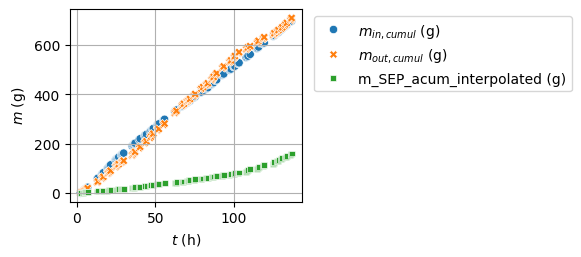

In [17]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'value',
             data=data[['t_h',
                        '$m_{in,cumul}$ (g)', 
                        '$m_{out,cumul}$ (g)',
                        'm_SEP_acum_interpolated (g)',
                       ]].melt(id_vars = 't_h'), 
             hue = 'variable',
             style = 'variable',
             ax = ax)

plt.grid('both')
# plt.ylim(0,1)
# plt.xlim(0,10)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.xlabel('$t$ (h)')
plt.ylabel('$m$ (g)')
fig_name = 'MB_cumul.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

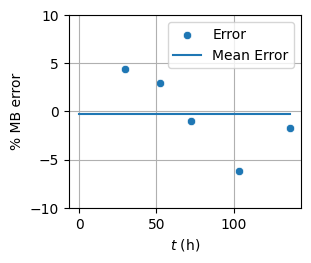

In [18]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'MB_error_perc',
             data=data.loc[data['LIQ_SAMPLE'] == 1],
             label = 'Error',
             ax = ax)

plt.grid('both')
plt.plot(np.linspace(0, data['t_h'].iloc[-1], 2), 
         (data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean(), 
          data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()), 
         label = 'Mean Error')
plt.ylim(-10,10)
# plt.xlim(0,80)
plt.legend()
plt.xlabel('$t$ (h)')
plt.ylabel('% MB error')
fig_name = 'MB_error.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [19]:
data.loc[data['LIQ_SAMPLE'] == 1]['MB_error_perc'].mean()

np.float64(-0.30400215774223155)

In [20]:
# now closing the mass balance using the integral mass balance to get the aprox liquid % in the outlet

In [21]:
data['$m_{total}$ (g/s)'] = data['$m_{in}$ (g/s)']

In [22]:
data['mass_frac_liq'] = data['m_SEP_acum_interpolated (g)']/data['$m_{in,cumul}$ (g)']

In [23]:
data['$m_{liq,out}$ (g/s)'] = data['$m_{total}$ (g/s)']*data['mass_frac_liq'].iloc[-1]

In [24]:
data['$m_{gas,out}$ (g/s)'] = data['$m_{total}$ (g/s)'] - data['$m_{liq,out}$ (g/s)']

In [25]:
data['$m_{out,cumul}$ (g)'] = (integrate.cumulative_trapezoid(data['$m_{gas,out}$ (g/s)'], 
                                                             data['t_s'], initial = 0)
                              + data['m_SEP_acum_interpolated (g)']
                              )

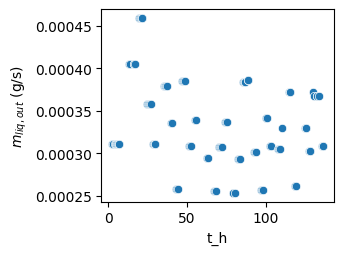

In [26]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = '$m_{liq,out}$ (g/s)',
             data=data,
             ax = ax)
plt.show()

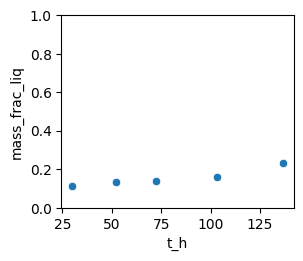

In [27]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y = 'mass_frac_liq',
             data=data.loc[data['LIQ_SAMPLE'] == 1], 
             ax = ax)
plt.ylim(0,1)
plt.show()

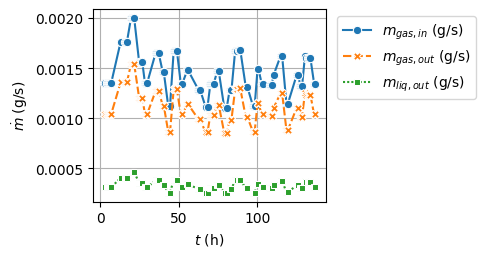

In [28]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.lineplot(x='t_h', y = 'value',
             data=data[['t_h',
                        'T_R_K',
                        '$m_{gas,in}$ (g/s)', 
                        '$m_{gas,out}$ (g/s)', 
                        '$m_{liq,out}$ (g/s)',
#                         '$m_{out}$ (g/s)',
#                         '$m_{in}$ (g/s)'
                       ]].melt(id_vars = ['t_h', 'T_R_K']), 
             hue = 'variable',
             style = 'variable',
#              size = 'T_R_K',
             markers = True,
             ax = ax)

plt.grid('both')
# plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.xlabel('$t$ (h)')
plt.ylabel('$\dot{m}$ (g/s)')
fig_name = 'MB.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [29]:
# recalculating gas outlet molar flow rates on reconciled data
data['F_gas_out (mol/s)'] = (data['F_H2_s_mol_s'] + data['F_CO_s_mol_s'] + data['F_CH4_s_mol_s']
                            + data['F_CO2_s_mol_s'] + data['F_C2H4_s_mol_s']
                             + data['F_C2H6_s_mol_s'] + data['F_C3H8_s_mol_s']
                            )
data['y_H2_out'] = data['F_H2_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CO_out'] = data['F_CO_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CH4_out'] = data['F_CH4_s_mol_s']/data['F_gas_out (mol/s)']
data['y_CO2_out'] = data['F_CO2_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C2H4_out'] = data['F_C2H4_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C2H6_out'] = data['F_C2H6_s_mol_s']/data['F_gas_out (mol/s)']
data['y_C3H8_out'] = data['F_C3H8_s_mol_s']/data['F_gas_out (mol/s)']
data['MM_mean_gas'] = (data['y_H2_out']*2 + data['y_CO_out']*(12+16) + data['y_CH4_out']*16
                  + data['y_CO2_out']*44 + data['y_C2H6_out']*((2*12)+6) + data['y_C3H8_out']*((3*12)+8))
data['F_gas_out (mol/s)'] = data['$m_{gas,out}$ (g/s)']/data['MM_mean_gas']
data['F_H2_s_mol_s'] = data['y_H2_out']*data['F_gas_out (mol/s)']
data['F_CO_s_mol_s'] = data['y_CO_out']*data['F_gas_out (mol/s)']
data['F_CH4_s_mol_s'] = data['y_CH4_out']*data['F_gas_out (mol/s)']
data['F_CO2_s_mol_s'] = data['y_CO2_out']*data['F_gas_out (mol/s)']
data['F_C2H4_s_mol_s'] = data['y_C2H4_out']*data['F_gas_out (mol/s)']
data['F_C2H6_s_mol_s'] = data['y_C2H6_out']*data['F_gas_out (mol/s)']
data['F_C3H8_s_mol_s'] = data['y_C3H8_out']*data['F_gas_out (mol/s)']

In [30]:
data['$m_{liq,out}$ (g/s)'].mean()

np.float64(0.0003322328590259137)

In [31]:
# using oxygen elemental balance to correct water flow and get a better estimation of liquid hydrocarbon flow
data['F_H2O_s_mol_s'] = data['F_CO_e_mol_s'] - data['F_CO_s_mol_s'] - 2*data['F_CO2_s_mol_s']
data['$m_{H_2O,out}$ (g/s)'] = data['F_H2O_s_mol_s']*18

In [32]:
# fração de cera no produto líquido medida na balanca
# antes da correção pelo BM da água
data['frac_cera'].mean()

np.float64(0.3494168548097545)

In [33]:
# m C5+ out before H2O elemental balance correction
data['$m_{C5+,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)']*data['frac_cera']
data['$m_{C5+,out}$ (g/s)'].mean()

np.float64(0.00011261610279892429)

In [34]:
# m C5+ out after H2O elemental balance correction
data['$m_{C5+,out}$ (g/s)'] = data['$m_{liq,out}$ (g/s)'] - data['$m_{H_2O,out}$ (g/s)']
data['$m_{C5+,out}$ (g/s)'].mean()

np.float64(0.00012398896336285125)

In [35]:
data['$m_{H_2O,out}$ (g/s)'].mean()

np.float64(0.00020824389566306248)

In [36]:
# fração de cera no produto líquido depois da correção pelo BM da água
data['frac_cera'] = data['$m_{C5+,out}$ (g/s)']/data['$m_{liq,out}$ (g/s)']
data['frac_cera'].mean()

np.float64(0.3695452642368965)

In [37]:
data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
     'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[[
       'w_C9', 'w_C10', 'w_C11', 'w_C12', 'w_C13', 'w_C14', 'w_C15', 'w_C16',
       'w_C17', 'w_C18', 'w_C19', 'w_C20', 'w_C21', 'w_C22', 'w_C23', 'w_C24',
       'w_C25', 'w_C26', 'w_C27', 'w_C28', 'w_C29', 'w_C30', 'w_C31', 'w_C32',
       'w_C33', 'w_C34', 'w_C35', 'w_C36',
        'w_C7_olef', 'w_C8_olef',
       'w_C9_olef', 'w_C10_olef', 'w_C11_olef', 'w_C12_olef', 'w_C13_olef',
       'w_C14_olef', 'w_C15_olef', 'w_C16_olef', 'w_C17_olef', 'w_C18_olef'       
               ]].multiply(
    data['$m_{C5+,out}$ (g/s)'], axis = 'index')

# molar masses of liquid hydrocarbons
MM_PARAFIN = [n*12+2*n+2 for n in range(9,37)]
MM_OLEF = [n*12+2*n for n in range(9,19)]
MM = np.concat((MM_PARAFIN, MM_OLEF))

# to remove Performance Warning
# PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 
# `frame.insert` many times, which has poor performance.  Consider joining all columns 
# at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
data = data.copy()

# F = mass flow/molar mass
data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
     ]] = data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
                                 ]].divide(MM, axis = 1)
data = data.copy()

/tmp/ipykernel_15172/1736902401.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[['F_C9', 'F_C10',


In [38]:
data['T_R_C'] = data['T_R_K'] - 273.15
data['$H_2/CO$'] = data['F_H2_e_mol_s']/data['F_CO_e_mol_s']
data['F_C1_C3_exp'] = (data['F_CH4_s_mol_s'] + data['F_C2H4_s_mol_s'] 
                       + data['F_C2H6_s_mol_s'] + data['F_C3H8_s_mol_s'])
data['F_C5+_exp'] = data[['F_C9', 'F_C10',
       'F_C11', 'F_C12', 'F_C13', 'F_C14', 'F_C15', 'F_C16', 'F_C17', 'F_C18',
       'F_C19', 'F_C20', 'F_C21', 'F_C22', 'F_C23', 'F_C24', 'F_C25', 'F_C26',
       'F_C27', 'F_C28', 'F_C29', 'F_C30', 'F_C31', 'F_C32', 'F_C33', 'F_C34',
       'F_C35', 'F_C36',
       'F_Olef_C7', 'F_Olef_C8', 'F_Olef_C9', 'F_Olef_C10',
       'F_Olef_C11', 'F_Olef_C12', 'F_Olef_C13', 'F_Olef_C14',
      'F_Olef_C15', 'F_Olef_C16', 'F_Olef_C17', 'F_Olef_C18'
       ]].sum(axis=1)
# data['alpha'] = (
#         (2.48e-15*data['P_abs_Pa']**2 - 1.19e-8*data['P_abs_Pa'] + 0.01597)*data['T_R_K'] +
#         (-1.5397e-12*data['P_abs_Pa']**2 + 6.8763e-6*data['P_abs_Pa'] - 7.7249)*(data['F_H2_e_mol_s']/data['F_CO_e_mol_s'])
#         )

In [39]:
# recalculating X on reconciled data
data['X_CO'] = (data['F_CO_e_mol_s'] - data['F_CO_s_mol_s']) / data['F_CO_e_mol_s']
data['X_H2'] = (data['F_H2_e_mol_s'] - data['F_H2_s_mol_s']) / data['F_H2_e_mol_s']

In [40]:
# calculating the alphas

In [41]:
data_ASF_F = pd.DataFrame()
data_ASF_F['F_C1'] = data['F_CH4_s_mol_s']
data_ASF_F['F_C2'] = data['F_C2H6_s_mol_s'] + data['F_C2H4_s_mol_s']
data_ASF_F['F_C3'] = data['F_C3H8_s_mol_s']
data_ASF_F['F_C9'] = data['F_C9'] + data['F_Olef_C9']
data_ASF_F['F_C10'] = data['F_C10'] + data['F_Olef_C10']
data_ASF_F['F_C11'] = data['F_C11'] + data['F_Olef_C11']
data_ASF_F['F_C12'] = data['F_C12'] + data['F_Olef_C12']
data_ASF_F['F_C13'] = data['F_C13'] + data['F_Olef_C13']
data_ASF_F['F_C14'] = data['F_C14'] + data['F_Olef_C14']
data_ASF_F['F_C15'] = data['F_C15'] + data['F_Olef_C15']
data_ASF_F['F_C16'] = data['F_C16'] + data['F_Olef_C16']
data_ASF_F['F_C17'] = data['F_C17'] + data['F_Olef_C17']
data_ASF_F['F_C18'] = data['F_C18'] + data['F_Olef_C18']
data_ASF_F['F_C19'] = data['F_C19']
data_ASF_F['F_C20'] = data['F_C20']
data_ASF_F['F_C21'] = data['F_C21']
data_ASF_F['F_C22'] = data['F_C22']
data_ASF_F['F_C23'] = data['F_C23']
data_ASF_F['F_C24'] = data['F_C24']
data_ASF_F['F_C25'] = data['F_C25']
data_ASF_F['F_C26'] = data['F_C26']
data_ASF_F['F_C27'] = data['F_C27']
data_ASF_F['F_C28'] = data['F_C28']
data_ASF_F['F_C29'] = data['F_C29']
data_ASF_F['F_C30'] = data['F_C30']
data_ASF_F['F_C31'] = data['F_C31']
data_ASF_F['F_C32'] = data['F_C32']
data_ASF_F['F_C33'] = data['F_C33']
data_ASF_F['F_C34'] = data['F_C34']
data_ASF_F['F_C35'] = data['F_C35']

# ignore PerformanceWarning: DataFrame is highly fragmented.  
# This is usually the result of calling `frame.insert` many times, which has poor performance.  
# Consider joining all columns at once using pd.concat(axis=1) instead. 
# To get a de-fragmented frame, use `newframe = frame.copy()`
from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

data_ASF_F[['y1', 'y2', 'y3', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14',
                                  'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24',
                                  'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33',
                                   'y34', 'y35']] = data_ASF_F.div(data_ASF_F.sum(axis=1), axis=0)

In [42]:
data['OL_P_2'] = data['F_C2H4_s_mol_s']/data['F_C2H6_s_mol_s']
data['OL_P_9'] = data['F_Olef_C9']/data['F_C9']
data['OL_P_10'] = data['F_Olef_C10']/data['F_C10']
data['OL_P_11'] = data['F_Olef_C11']/data['F_C11']
data['OL_P_12'] = data['F_Olef_C12']/data['F_C12']
data['OL_P_13'] = data['F_Olef_C13']/data['F_C13']
data['OL_P_14'] = data['F_Olef_C14']/data['F_C14']
data['OL_P_15'] = data['F_Olef_C15']/data['F_C15']
data['OL_P_16'] = data['F_Olef_C16']/data['F_C16']
data['OL_P_17'] = data['F_Olef_C17']/data['F_C17']
data['OL_P_18'] = data['F_Olef_C18']/data['F_C18']

In [43]:
def SSR(params, y_exp):
    ssr = 0
    alpha = params[0]
    K_C2 = params[1]
    K_C3 = params[2]
#     print(alpha)
#     clear_output(wait=True)
    n = np.concat(([1,2,3],list(range(9,36))))
    for i in range(len(y_exp)):
        y_n_model = (1-alpha)*alpha**(n[i]-1 + K_C2*(n[i] == 2) + K_C3*(n[i] == 3))
        ssr = ssr + (y_exp[i] - y_n_model)**2
#     print(ssr)
    return ssr

In [44]:
data['alpha'] = 0.8 # initial estimate
data['K_C2'] = 5.0 # initial estimate
data['K_C3'] = 5.0 # initial estimate

bnds = ((0, 1), (None, None), (None, None))

for i in data_ASF_F.index:
    y_exp = data_ASF_F[['y1', 'y2', 'y3', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14',
                                  'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24',
                                  'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33',
                                   'y34', 'y35']].loc[i].values
    minimum = minimize(SSR, data[['alpha', 'K_C2', 'K_C3']].loc[i], method = 'Nelder-Mead',
                               bounds = bnds,
    #                            options={'maxfev':max_fev}, 
                               args = (y_exp))
    data.loc[i ,'alpha'] = minimum.x[0]
    data.loc[i ,'K_C2'] = minimum.x[1]
    data.loc[i ,'K_C3'] = minimum.x[2]

In [45]:
y_n_dist_exp = data_ASF_F[['y1', 'y2', 'y3', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14',
                                  'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24',
                                  'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33',
                                   'y34', 'y35']]

In [46]:
data = data.join(y_n_dist_exp)

In [47]:
# save reconciled data
with open('reconciled_data_validation.pkl', 'wb') as f:
    pickle.dump(data, f)

In [48]:
data.to_excel('reconciled_data_validation.ods')

In [49]:
# plot alphas

In [50]:
data['P (bar)'] = data['P_abs_Pa']/1e5

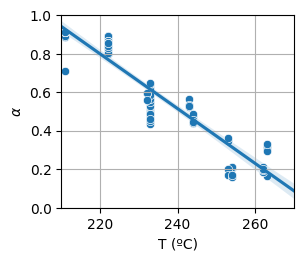

In [51]:
fig, ax = plt.subplots(figsize=(3,2.5))
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] < 1.6e6)],
#             ax = ax, label = '15 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 1.6) & 
#                                               (data['P_abs_Pa'] < 2e6)],
#             ax = ax, label = '17.5 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 2e6) & 
#                                               (data['P_abs_Pa'] < 2.2e6)],
#             ax = ax, label = '20 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 2.2) & 
#                                               (data['P_abs_Pa'] < 2.5e6)],
#             ax = ax, label = '22.5 bar')
# sns.regplot(x='T_R_K', y='alpha',
#              data=data.loc[(data['P_abs_Pa'] > 2.5e6)],
#             ax = ax, label = '25 bar')
plt.xlim(210,270)
sns.regplot(x='T_R_C', y='alpha',
             data=data.loc[data['CINÉTICA'] == True], scatter = False,
            ax = ax, truncate = False)
sns.scatterplot(x='T_R_C', y='alpha',
             data=data,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel(r'$\alpha$')
plt.xlabel('T (ºC)')
plt.ylim(0,1)
fig_name = 'alpha_vs_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

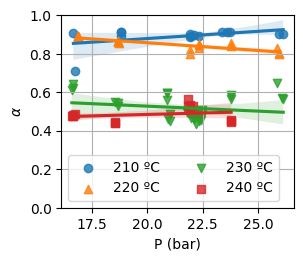

In [52]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] < (219+273))],
           label = '210 ºC', marker = 'o', line_kws = {'linestyle': '-'})
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] > (219+273)) & 
                                              (data['T_R_K'] < (229+273))],
           label = '220 ºC', marker = '^', line_kws = {'linestyle': '-'})
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] > (229+273)) & 
                                              (data['T_R_K'] < (239+273))],
           label = '230 ºC', marker = 'v', line_kws = {'linestyle': '-'})
sns.regplot(x='P (bar)', y='alpha',
             data=data.loc[(data['T_R_K'] > (239+273)) & 
                                              (data['T_R_K'] < (249+273))],
           label = '240 ºC', marker = 's', 
           line_kws = {'linestyle': '-'})
# sns.regplot(x='P (bar)', y='alpha',
#              data=data.loc[(data['T_R_K'] > (249+273)) & 
#                                               (data['T_R_K'] < (259+273))],
#            label = '250 ºC', marker = 'D', 
#            line_kws = {'linestyle': '-'})
# sns.regplot(x='P (bar)', y='alpha',
#              data=data.loc[(data['T_R_K'] > (259+273)) & 
#                                               (data['T_R_K'] < (269+273))],
#            label = '260 ºC', marker = 'p', 
#            line_kws = {'linestyle': '-'})

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.legend(ncols = 2)
plt.ylim(0,1)
plt.ylabel(r'$\alpha$')
plt.xlabel('P (bar)')
fig_name = 'alpha_vs_P.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

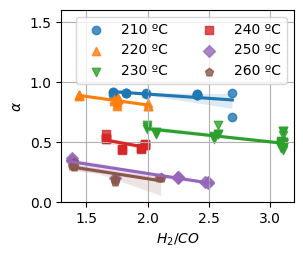

In [53]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] < (219+273))],
           label = '210 ºC', marker = 'o', line_kws = {'linestyle': '-'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (219+273)) & 
                                              (data['T_R_K'] < (229+273))],
           label = '220 ºC', marker = '^', line_kws = {'linestyle': '-'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (229+273)) & 
                                              (data['T_R_K'] < (239+273))],
           label = '230 ºC', marker = 'v', line_kws = {'linestyle': '-'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (239+273)) & 
                                              (data['T_R_K'] < (249+273))],
           label = '240 ºC', marker = 's', line_kws = {'linestyle': '-'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (249+273)) & 
                                              (data['T_R_K'] < (259+273))],
           label = '250 ºC', marker = 'D', line_kws = {'linestyle': '-'})
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['T_R_K'] > (259+273)) & 
                                              (data['T_R_K'] < (269+273))],
           label = '260 ºC', marker = 'p', line_kws = {'linestyle': '-'})

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.legend(ncols = 2)
plt.ylabel(r'$\alpha$')
plt.ylim(0,1.6)
fig_name = 'alpha_vs_H2_CO.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

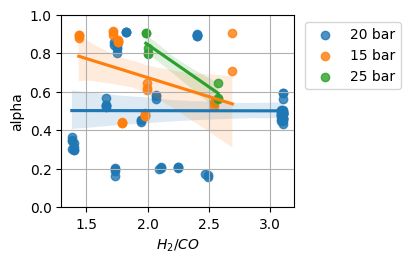

In [54]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['P_abs_Pa'] > 2e6) & 
                                              (data['P_abs_Pa'] < 2.5e6)],
            ax = ax, label = '20 bar')
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['P_abs_Pa'] < 2e6)],
            ax = ax, label = '15 bar')
sns.regplot(x='$H_2/CO$', y='alpha',
             data=data.loc[(data['P_abs_Pa'] > 2.5e6)],
            ax = ax, label = '25 bar')

plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

In [55]:
# alpha regressions

In [56]:
def alphas(model_n, data, beta):
    T = data['T_R_K']
    P = data['P_abs_Pa']
    H2_CO = data['F_H2_e_mol_s']/data['F_CO_e_mol_s']
    match model_n:
        case 'model_1':
            return beta[0] + beta[1]*T + beta[2]*H2_CO + beta[3]*P + beta[4]*P**2
        case 'model_2':
            return beta[0] + beta[1]*T + beta[2]*H2_CO
        case 'model_3':
            return 1/(1 + e**-(beta[0] + beta[1]*T + beta[2]*H2_CO))
        case 'model_4':
            return 1/(1 + e**-(beta[0] + beta[1]*T))
        case 'model_5':
            return 1/(1 + e**-(beta[0] + beta[1]*T + beta[2]*H2_CO) + beta[3]*P + beta[4]*P**2)
        case 'model_6':
            return beta[0]*e**(-beta[1]*T -beta[2]*H2_CO)

In [57]:
def SSR_alpha_fit(beta, data, model_n):
    print(beta)
    clear_output(wait=True)
    ssr = 0
    alpha_model = alphas(model_n, data, beta)
    ssr = (data['alpha'] - alpha_model).pow(2).sum().sum()
    print(ssr)
    return ssr

In [58]:
def neg_logLik(beta, data, model_n):
    print(beta)
    clear_output(wait=True)
    alpha_model = alphas(model_n, data, beta)
    residuals = data['alpha'] - alpha_model
    # drop column if all NA
    residuals.dropna(how = 'all', inplace = True)
    residuals_flat = pd.DataFrame()
    residuals_flat['residuals_flat'] = residuals.values.flatten()
    neg_logLik = -norm.logpdf(residuals_flat,
                             residuals_flat.describe().loc['mean'],
                             residuals_flat.describe().loc['std']).sum()
    print(neg_logLik)
    return neg_logLik

In [59]:
minimums_alpha = pd.DataFrame(columns = ['model','fun','params', 'aic', 'nfev',
                                               'success', 'message'])

In [60]:
beta_model_1 = [1, 1e-3, 1e-1, 1e-5, 1e-10]

minimum_model_1 = minimize(SSR_alpha_fit, beta_model_1, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data.loc[data.CINÉTICA == True], 'model_1'))
beta = minimum_model_1.x
K = len(beta) + 1
N = len(data.loc[data.CINÉTICA == True])
aic = 2*K + 2*neg_logLik(beta, data.loc[data.CINÉTICA == True], 'model_1') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[0] = ['model_1', minimum_model_1.fun, minimum_model_1.x, aic,
                           minimum_model_1.nfev, minimum_model_1.success, minimum_model_1.message]

14.879895746315931


In [61]:
beta_model_2 = [1, 1e-3, 1e-1]

minimum_model_2 = minimize(SSR_alpha_fit, beta_model_2, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data.loc[data.CINÉTICA == True], 'model_2'))
beta = minimum_model_2.x
K = len(beta) + 1
N = len(data.loc[data.CINÉTICA == True])
aic = 2*K + 2*neg_logLik(beta, data.loc[data.CINÉTICA == True], 'model_2') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[1] = ['model_2', minimum_model_2.fun, minimum_model_2.x, aic,
                           minimum_model_2.nfev, minimum_model_2.success, minimum_model_2.message]

-140.66758188442603


In [62]:
beta_model_3 = [1, 1e-3, 1e-1]

minimum_model_3 = minimize(SSR_alpha_fit, beta_model_3, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data.loc[data.CINÉTICA == True], 'model_3'))
beta = minimum_model_3.x
K = len(beta) + 1
N = len(data.loc[data.CINÉTICA == True])
aic = 2*K + 2*neg_logLik(beta, data.loc[data.CINÉTICA == True], 'model_3') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[2] = ['model_3', minimum_model_3.fun, minimum_model_3.x, aic,
                           minimum_model_3.nfev, minimum_model_3.success, minimum_model_3.message]

-152.12471858065894


In [63]:
beta_model_4 = [1, 1e-3]

minimum_model_4 = minimize(SSR_alpha_fit, beta_model_4, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data.loc[data.CINÉTICA == True], 'model_4'))
beta = minimum_model_4.x
K = len(beta) + 1
N = len(data.loc[data.CINÉTICA == True])
aic = 2*K + 2*neg_logLik(beta, data.loc[data.CINÉTICA == True], 'model_4') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[3] = ['model_4', minimum_model_4.fun, minimum_model_4.x, aic,
                           minimum_model_4.nfev, minimum_model_4.success, minimum_model_4.message]

-101.81846562496239


In [64]:
beta_model_5 = [1, 1e-3, 1e-1, 1e-5, 1e-10]

minimum_model_5 = minimize(SSR_alpha_fit, beta_model_5, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data.loc[data.CINÉTICA == True], 'model_5'))
beta = minimum_model_5.x
K = len(beta) + 1
N = len(data.loc[data.CINÉTICA == True])
aic = 2*K + 2*neg_logLik(beta, data.loc[data.CINÉTICA == True], 'model_5') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[4] = ['model_5', minimum_model_5.fun, minimum_model_5.x, aic,
                           minimum_model_5.nfev, minimum_model_5.success, minimum_model_5.message]

2.8105661694327213


In [65]:
beta_model_6 = [1, 1e-3, 1e-1]

minimum_model_6 = minimize(SSR_alpha_fit, beta_model_6, method = 'Nelder-Mead',
                               bounds = None,
    #                            options={'maxfev':max_fev}, 
                               args = (data.loc[data.CINÉTICA == True], 'model_6'))
beta = minimum_model_6.x
K = len(beta) + 1
N = len(data.loc[data.CINÉTICA == True])
aic = 2*K + 2*neg_logLik(beta, data.loc[data.CINÉTICA == True], 'model_6') + (2*K**2 + 2*K)/(N - K - 1) 
# AIC corrigido para tamanho amostral pequeno
aic
minimums_alpha.loc[5] = ['model_6', minimum_model_6.fun, minimum_model_6.x, aic,
                           minimum_model_6.nfev, minimum_model_6.success, minimum_model_6.message]

-95.52367885554011


In [66]:
minimums_alpha['rel_lik'] = e**((minimums_alpha['aic'].min()-minimums_alpha['aic'])/2)


In [67]:
minimums_alpha

,model,fun,params,aic,nfev,success,message,rel_lik
0,model_1,7.116804,"[0.8213013272521679, 0.0011923941703479658, 0....",42.823083,343,True,Optimization terminated successfully.,3.010032e-74
1,model_2,0.191104,"[8.448145910227328, -0.014899047747428264, -0....",-272.841337,209,True,Optimization terminated successfully.,1.057374e-05
2,model_3,0.146574,"[39.79173657617973, -0.0745232096252458, -0.73...",-295.755610,240,True,Optimization terminated successfully.,1.000000e+00
3,model_4,0.474202,"[35.81944639583261, -0.06967022347923482]",-197.344248,133,True,Optimization terminated successfully.,4.268196e-22
4,model_5,5.375075,"[3.013293763499764, 0.0008189170492530571, 0.1...",18.684423,362,True,Optimization terminated successfully.,5.250665e-69
5,model_6,0.546895,"[30620.324923798624, 0.02082161243510447, 0.16...",-182.553531,600,False,Maximum number of function evaluations has bee...,2.621083e-25


In [68]:
minimum_model_3.x

array([39.79173658, -0.07452321, -0.73213305])

In [69]:
# save best alpha model params
with open('alpha_params.pkl', 'wb') as f:
    pickle.dump(minimum_model_3.x, f)

In [70]:
data['alpha_model_1'] = alphas('model_1', data, minimum_model_1.x)
data['alpha_model_2'] = alphas('model_2', data, minimum_model_2.x)
data['alpha_model_3'] = alphas('model_3', data, minimum_model_3.x)
data['alpha_model_4'] = alphas('model_4', data, minimum_model_4.x)
data['alpha_model_5'] = alphas('model_5', data, minimum_model_5.x)
data['alpha_model_6'] = alphas('model_6', data, minimum_model_6.x)

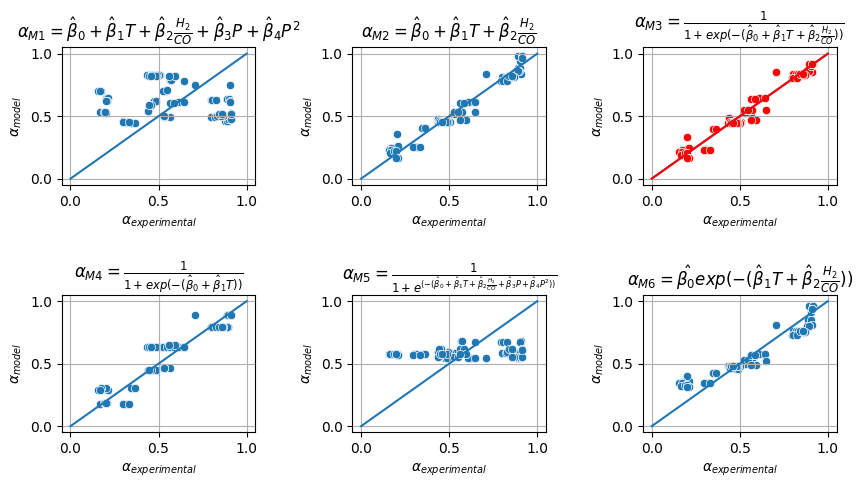

In [71]:
fig, ax = plt.subplots(2,3,figsize=(10,5))
plt.subplots_adjust(hspace=0.8, wspace = 0.5)
sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_1", 
                ax = ax[0,0],
)
ax[0,0].set_title(r'$\alpha_{M1} = \hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO} + \hat{\beta}_3 P + \hat{\beta}_4 P^2$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_2", 
                ax = ax[0,1],
)
ax[0,1].set_title(r'$\alpha_{M2} = \hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_3", 
                color = 'red',
                ax = ax[0,2],
)
ax[0,2].set_title(r'$\alpha_{M3} = \frac{1}{1 + exp(-(\hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_4", 
                ax = ax[1,0],
)
ax[1,0].set_title(r'$\alpha_{M4} = \frac{1}{1 + exp(-(\hat{\beta}_0 + \hat{\beta}_1 T))}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_5", 
                ax = ax[1,1],
)
ax[1,1].set_title(r'$\alpha_{M5} = \frac{1}{1 + e^{(-(\hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO} + \hat{\beta}_3 P + \hat{\beta}_4 P^2))}}$')

sns.scatterplot(
    data = data,
                x="alpha", 
                y="alpha_model_6", 
                ax = ax[1,2],
)
ax[1,2].set_title(r'$\alpha_{M6} = \hat{\beta_0} exp(-(\hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))$')

for i in range(2):
    for j in range(3):
        ax[i,j].grid('both')
        ax[i,j].set_xlabel(r'$\alpha_{experimental}$')
        ax[i,j].set_ylabel(r'$\alpha_{model}$')
        ax[i,j].plot(np.linspace(0,1,num = 10), np.linspace(0,1, num = 10))
ax[0,2].plot(np.linspace(0,1,num = 10), np.linspace(0,1, num = 10), color = 'red')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ticklabel_format(axis='both', style='sci', scilimits=(0,0))
# plt.yscale('log')
# plt.xscale('log')
# plt.ylabel('$alpha_{model}$')
# plt.xlabel('$alpha_{experimental}$')
# plt.xlim(0,1)
# plt.ylim(0,1)
fig_name = 'alpha_parity.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, bbox_inches = 'tight')

In [72]:
# plot the models
T, H2_CO = np.mgrid[(180+273):(350+273):5, 1:4:1]

alpha_best_models = pd.DataFrame()

alpha_best_models['T_R_K'] = T.flatten()
alpha_best_models['T (ºC)'] = alpha_best_models['T_R_K'] - 273
alpha_best_models['$H_2/CO$'] = H2_CO.flatten()
alpha_best_models['P_abs_Pa'] = 2e6
alpha_best_models['F_CO_e_mol_s'] = 1
alpha_best_models['F_H2_e_mol_s'] = alpha_best_models['$H_2/CO$']*alpha_best_models['F_CO_e_mol_s']

alpha_best_models['alpha_model_2'] = alphas('model_2', alpha_best_models, minimum_model_2.x)
alpha_best_models['alpha_model_3'] = alphas('model_3', alpha_best_models, minimum_model_3.x)
alpha_best_models['alpha_model_6'] = alphas('model_6', alpha_best_models, minimum_model_6.x)

/tmp/ipykernel_15172/429558533.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='T (ºC)', y='alpha',
/tmp/ipykernel_15172/429558533.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='T (ºC)', y='alpha',


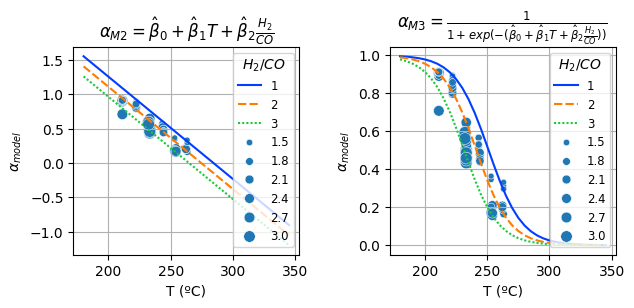

In [73]:
fig, ax = plt.subplots(1,2,figsize=(7,2.7))
plt.subplots_adjust(hspace=0.8, wspace = 0.4)
sns.lineplot(x='T (ºC)', y='value',
             data=alpha_best_models[['T (ºC)', '$H_2/CO$',
                                    'alpha_model_2',
                                    ]].melt(id_vars = ['T (ºC)', '$H_2/CO$']), 
             style = '$H_2/CO$',
             hue = '$H_2/CO$',
             palette = "bright",
             ax = ax[0])
ax[0].set_title(r'$\alpha_{M2} = \hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}$')

sns.scatterplot(x='T (ºC)', y='alpha',
             data=data, 
             size = '$H_2/CO$',
             palette = "bright",
             legend = 'brief',
             ax = ax[0])

sns.lineplot(x='T (ºC)', y='value',
             data=alpha_best_models[['T (ºC)', '$H_2/CO$',
                                    'alpha_model_3',
                                    ]].melt(id_vars = ['T (ºC)', '$H_2/CO$']), 
             style = '$H_2/CO$',
             hue = '$H_2/CO$',
             palette = "bright",
             ax = ax[1])
ax[1].set_title(r'$\alpha_{M3} = \frac{1}{1 + exp(-(\hat{\beta}_0 + \hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))}$')

sns.scatterplot(x='T (ºC)', y='alpha',
             data=data, 
             size = '$H_2/CO$',
             palette = "bright",
             legend = 'brief',
             ax = ax[1])

# sns.lineplot(x='T (ºC)', y='value',
#              data=alpha_best_models[['T (ºC)', '$H_2/CO$',
#                                     'alpha_model_6',
#                                     ]].melt(id_vars = ['T (ºC)', '$H_2/CO$']), 
#              style = '$H_2/CO$',
#              hue = '$H_2/CO$',
#              palette = "bright",
#              ax = ax[2])
# ax[2].set_title(r'$\alpha_{M6} = \hat{\beta_0} exp(-(\hat{\beta}_1 T + \hat{\beta}_2 \frac{H_2}{CO}))$')

# sns.scatterplot(x='T (ºC)', y='alpha',
#              data=data, 
#              size = '$H_2/CO$',
#              palette = "bright",
#              legend = 'brief',
#              ax = ax[2])

for i in range(2):
    ax[i].grid('both')
    ax[i].set_xlabel('T (ºC)')
    ax[i].set_ylabel(r'$\alpha_{model}$')
    ax[i].legend(title = '$H_2/CO$', ncols = 1, fontsize='small')
# plt.grid('both')
# plt.ylim(0,None)
# # plt.xlim(0,80)
# plt.legend(title = '$H_2/CO$', bbox_to_anchor=(1.02, 1))
# plt.ylabel(r'$\alpha$')
# plt.xlabel('$T$ (K)')
fig_name = 'alpha_models.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [74]:
# visualizing the oleffin/paraffin ratio
OL_P = data[['T_R_K', '$H_2/CO$',
        'OL_P_2', 'OL_P_9', 'OL_P_10', 'OL_P_11', 'OL_P_12', 'OL_P_13', 'OL_P_14',
        'OL_P_15', 'OL_P_16', 'OL_P_17', 'OL_P_18'
        ]].melt(id_vars = ['T_R_K', '$H_2/CO$'],
               var_name = 'n_C', value_name = 'OL_P_ratio')
OL_P = OL_P.replace([np.inf, -np.inf], np.nan)
OL_P = OL_P.dropna()
OL_P = OL_P.replace({
    'OL_P_2': 2, 
    'OL_P_9':9,
    'OL_P_10':10,
    'OL_P_11':11,
    'OL_P_12':12,
    'OL_P_13':13,
    'OL_P_14':14,
    'OL_P_15':15,
    'OL_P_16':16,
    'OL_P_17':17,
    'OL_P_18':18,
}
                   ).infer_objects(copy=False)
OL_P

/tmp/ipykernel_15172/3685867116.py:22: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  ).infer_objects(copy=False)


,T_R_K,$H_2/CO$,n_C,OL_P_ratio
0,506.15,3.087668,2,0.190313
1,506.15,3.087668,2,0.190313
2,506.15,3.087668,2,0.190313
3,506.15,3.087668,2,0.227040
4,506.15,3.087668,2,0.269610
...,...,...,...,...
1194,536.15,1.402678,18,0.000000
1195,536.15,1.402678,18,0.000000
1196,505.15,3.107949,18,0.000000
1197,505.15,3.107949,18,0.000000


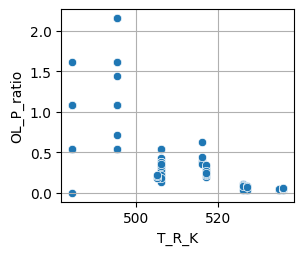

In [75]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='T_R_K', y='OL_P_ratio',
             data=OL_P.loc[OL_P['n_C'] == 2],
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

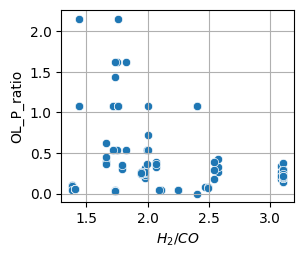

In [76]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='$H_2/CO$', y='OL_P_ratio',
             data=OL_P.loc[OL_P['n_C'] == 2],
            ax = ax)

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

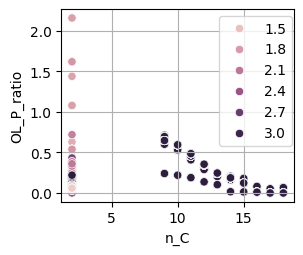

In [77]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='n_C', y='OL_P_ratio',
             data=OL_P,
            hue = '$H_2/CO$',
            ax = ax)

plt.grid('both')
plt.legend(bbox_to_anchor=(1.02, 1))
# plt.ylim(0,1)

# plt.ylim(0,None)
# fig_name = 'T_vs_r_mass_T.pdf'
# # plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
# #             bbox_inches = 'tight')
plt.show()

In [78]:
kinetic_data = data.loc[data['CINÉTICA'] == 1.0].reset_index()
plot_data = data.loc[(data['DESATIVAÇÃO'] == 1.0) | (data['CINÉTICA'] == 1.0)].reset_index()
deactivation_data = data.loc[data['DESATIVAÇÃO'] == 1.0].reset_index()
data_mass_T = pd.read_excel('data_mass_T.ods')
data_mass_T = data_mass_T.loc[data_mass_T['MASS_T'] == 1.0].reset_index()
data_mass_T['-r_CO'] = -(data_mass_T['F_CO_s_mol_s'] - data_mass_T['F_CO_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['-r_H2'] = -(data_mass_T['F_H2_s_mol_s'] - data_mass_T['F_H2_e_mol_s'])/data_mass_T['m_cat_g']
data_mass_T['T_R_C'] = data_mass_T['T_R_K'] - 273.15

In [79]:
from sklearn.model_selection import train_test_split

fitting_data, test_data = train_test_split(kinetic_data, test_size=0.4, random_state=105)
fitting_data = fitting_data.reset_index()
test_data = test_data.reset_index()

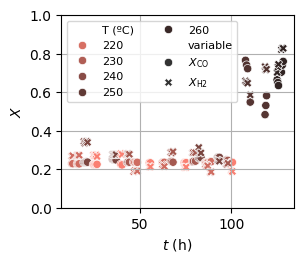

In [80]:
fig, ax = plt.subplots(figsize=(3,2.5))
plot_data_kinetics = data.loc[~(data.T_R_C > 250) | ~(data.X_CO < 0.4)].loc[(data.CINÉTICA == True) 
    & (data.DESATIVAÇÃO == False)][['t_h', 'X_CO', 'X_H2', 'T_R_C']]
plot_data_kinetics.columns = ['t (h)', '$X_\mathrm{CO}$', '$X_\mathrm{H2}$', 'T (ºC)']
plot_data_kinetics = plot_data_kinetics.melt(id_vars = ['t (h)', 'T (ºC)'])
sns.scatterplot(data = plot_data_kinetics,
               x = 't (h)', y = 'value', hue = 'T (ºC)', style = 'variable', palette = 'dark:salmon_r')

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.legend(ncols = 2, fontsize = 8)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_kinetics.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [104]:
# fit exponential X = a exp(b/T)
X = (data['T_R_C'].values)
y_CO = (data['X_CO'].values)
y_H2 = (data['X_H2'].values)

from scipy.optimize import curve_fit

def sigmoid(x, L ,x0, k, b):
    y = L / (1 + np.exp(-k*(x-x0))) + b
    return (y)

p0_H2 = [max(y_H2), np.median(X),1,min(y_H2)] # this is an mandatory initial guess
p0_CO = [max(y_CO), np.median(X),1,min(y_CO)] # this is an mandatory initial guess

popt_H2, pcov_H2 = curve_fit(sigmoid, X, y_H2,p0_H2, method='dogbox')
popt_CO, pcov_CO = curve_fit(sigmoid, X, y_CO,p0_CO, method='dogbox')

/tmp/ipykernel_15172/3044652656.py:9: RuntimeWarning: overflow encountered in exp
  y = L / (1 + np.exp(-k*(x-x0))) + b


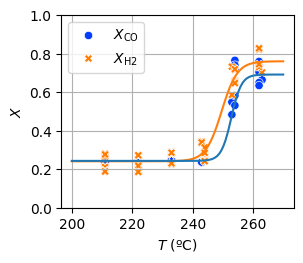

In [107]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(data = plot_data_kinetics,
               x = 'T (ºC)', y = 'value', hue = 'variable', style = 'variable', palette = 'bright')
X = np.linspace(200, 270, num = 100)
y_H2 = sigmoid(X, *popt_H2)
y_CO = sigmoid(X, *[4.48503023e-01, 2.52822862e+02, 0.6, 2.43331488e-01])
plt.plot(X, y_H2, color = sns.color_palette()[1])
plt.plot(X, y_CO, color = sns.color_palette()[0])

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$X$')
fig_name = 'X_vs_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

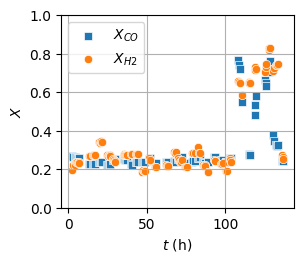

In [83]:
fig, ax = plt.subplots(figsize=(3,2.5))
sns.scatterplot(x='t_h', y='X_CO',
             data=data, ax = ax, marker = 's', label = '$X_{CO}$')
sns.scatterplot(x='t_h', y='X_H2',
             data=data, ax = ax, marker = 'o', label = '$X_{H2}$')

plt.grid('both')
plt.ylim(0,1)
# plt.xlim(0,80)
plt.legend(title=None)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
plt.show()

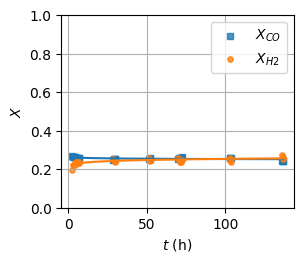

In [84]:
fig, ax = plt.subplots(figsize=(3,2.5))
line_w = 1.5
scatter_s = 15
sns.regplot(x='t_h', y='X_CO',
             data=deactivation_data, logx = True, 
            ax = ax, marker = 's', label = '$X_{CO}$',
           line_kws = {'linewidth': line_w}, scatter_kws= {'s': scatter_s})
sns.regplot(x='t_h', y='X_H2',
             data=deactivation_data, logx = True, 
            ax = ax, marker = 'o', label = '$X_{H2}$',
           line_kws = {'linewidth': line_w}, scatter_kws= {'s': scatter_s})

plt.grid('both')
plt.legend()
plt.ylim(0,1)
# plt.xlim(0,80)
plt.xlabel('$t$ (h)')
plt.ylabel('$X$')
fig_name = 'X_deactivation.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

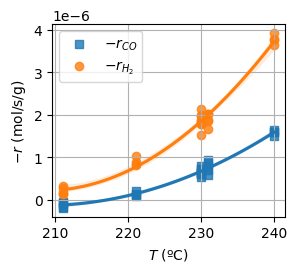

In [85]:
fig, ax = plt.subplots(figsize=(3,2.5))
# sns.lineplot(x='T_R_C', y='-r_CO',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_CO',
             data=data_mass_T, ax = ax, marker = 's', label = '$-r_{CO}$', order = 2)
# sns.lineplot(x='T_R_C', y='-r_H2',
#              data=data_mass_T, ax = ax)
sns.regplot(x='T_R_C', y='-r_H2',
             data=data_mass_T, ax = ax, marker = 'o', label = '$-r_{H_2}$', order = 2)

plt.grid('both')
plt.legend()
# plt.ylim(0,None)
plt.xlabel('$T$ (ºC)')
plt.ylabel('$-r$ (mol/s/g)')
fig_name = 'T_vs_r_mass_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [86]:
# plotting the K_Cs

In [87]:
# ignore K_C outliers
data_K_C = data[(np.abs(stats.zscore(data[['K_C2', 'K_C3']])) < 1.5).all(axis=1)].copy()

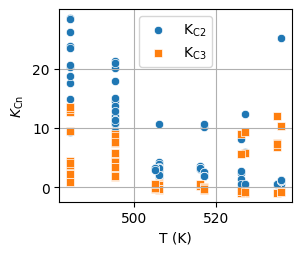

In [88]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.scatterplot(x='T_R_K', y='K_C2',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = '$\mathrm{K_{C2}}$', marker = 'o')

sns.scatterplot(x='T_R_K', y='K_C3',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = '$\mathrm{K_{C3}}$', marker = 's')

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel(r'$K_{\mathrm{Cn}}$')
plt.xlabel('T (K)')
# plt.ylim(0,25)
fig_name = 'K_C_vs_T.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [89]:
K_C2 = data_K_C.loc[data_K_C.T_R_K >= 500].K_C2.mean()

K_C3 = data_K_C.loc[data_K_C.T_R_K >= 500].K_C3.mean()
K_C2, K_C3

(np.float64(3.1246421710760237), np.float64(0.8094063839786738))

In [90]:
K_C2_std = data_K_C.loc[data_K_C.T_R_K >= 500].K_C2.std()

K_C3_std = data_K_C.loc[data_K_C.T_R_K >= 500].K_C3.std()
K_C2_std, K_C3_std

(np.float64(3.423400236659309), np.float64(2.8252715524915546))

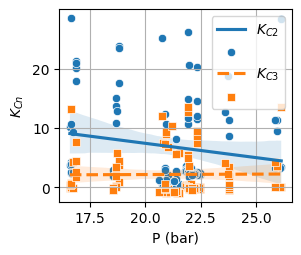

In [91]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.regplot(x='P (bar)', y='K_C2',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C2}$', line_kws = {'linestyle': '-'})
sns.scatterplot(x='P (bar)', y='K_C2',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = ' ', marker = 'o')
sns.regplot(x='P (bar)', y='K_C3',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C3}$', line_kws = {'linestyle': '--'})
sns.scatterplot(x='P (bar)', y='K_C3',
             data=data_K_C,
#             hue = 'P (bar)',
#             size = 'P (bar)',
            ax = ax, label = ' ', marker = 's')

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel('$K_{Cn}$')
plt.xlabel('P (bar)')
# plt.ylim(0,25)
fig_name = 'K_C_vs_P.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

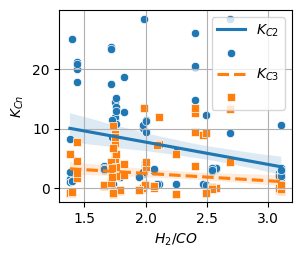

In [92]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.regplot(x='$H_2/CO$', y='K_C2',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C2}$', line_kws = {'linestyle': '-'})
sns.scatterplot(x='$H_2/CO$', y='K_C2',
             data=data_K_C,
#             hue = '$H_2/CO$',
#             size = '$H_2/CO$',
            ax = ax, label = ' ', marker = 'o')
sns.regplot(x='$H_2/CO$', y='K_C3',
             data=data_K_C, scatter = False,
            ax = ax, label = '$K_{C3}$', line_kws = {'linestyle': '--'})
sns.scatterplot(x='$H_2/CO$', y='K_C3',
             data=data_K_C,
#             hue = '$H_2/CO$',
#             size = '$H_2/CO$',
            ax = ax, label = ' ', marker = 's')

plt.grid('both')
# plt.legend(bbox_to_anchor=(1.02, 1))
plt.ylabel('$K_{Cn}$')
plt.xlabel('$H_2/CO$')
# plt.ylim(0,25)
fig_name = 'K_C_vs_H2_CO.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')
plt.show()

In [93]:
y_n = data_ASF_F[['y1', 'y2', 'y3', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14',
       'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24',
       'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33', 'y34',
       'y35']].copy()
y_n['index'] = data_ASF_F.index
y_n['T_R_K'] = data['T_R_K']
y_n['H2_CO'] = data['F_H2_e_mol_s'] / data['F_CO_e_mol_s']
y_n

,y1,y2,y3,y9,y10,y11,y12,y13,y14,y15,...,y29,y30,y31,y32,y33,y34,y35,index,T_R_K,H2_CO
40,0.525753,0.048122,0.148998,0.011455,0.024943,0.028380,0.026487,0.023509,0.021560,0.019794,...,0.001137,0.000786,0.000644,0.000539,0.000450,0.000207,0.000181,40,506.15,3.087668
41,0.518172,0.046299,0.148296,0.011872,0.025852,0.029415,0.027453,0.024366,0.022346,0.020516,...,0.001179,0.000815,0.000667,0.000559,0.000466,0.000215,0.000188,41,506.15,3.087668
42,0.519914,0.045374,0.145335,0.011961,0.026045,0.029635,0.027658,0.024548,0.022513,0.020669,...,0.001188,0.000821,0.000672,0.000563,0.000470,0.000216,0.000189,42,506.15,3.087668
43,0.521231,0.053235,0.133198,0.012083,0.026312,0.029938,0.027941,0.024799,0.022743,0.020881,...,0.001200,0.000829,0.000679,0.000568,0.000475,0.000219,0.000191,43,506.15,3.087668
44,0.508195,0.045583,0.150289,0.012232,0.026636,0.030306,0.028284,0.025104,0.023023,0.021137,...,0.001215,0.000840,0.000687,0.000575,0.000480,0.000221,0.000193,44,506.15,3.087668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,0.703997,0.048730,0.147167,0.002876,0.007931,0.009352,0.009241,0.008916,0.008044,0.007095,...,0.001019,0.000785,0.000535,0.000319,0.000210,0.000144,0.000082,271,536.15,1.402678
272,0.667944,0.056416,0.172531,0.002962,0.008169,0.009633,0.009518,0.009184,0.008286,0.007308,...,0.001050,0.000809,0.000551,0.000328,0.000216,0.000149,0.000084,272,536.15,1.402678
276,0.409773,0.044163,0.166092,0.010917,0.030103,0.035498,0.035075,0.033844,0.030533,0.026930,...,0.003869,0.002981,0.002029,0.001209,0.000795,0.000548,0.000310,276,505.15,3.107949
277,0.410408,0.043654,0.156416,0.011191,0.030859,0.036390,0.035956,0.034695,0.031301,0.027607,...,0.003967,0.003056,0.002080,0.001240,0.000815,0.000561,0.000318,277,505.15,3.107949


In [94]:
y_n = y_n.melt(id_vars = ['T_R_K', 'H2_CO', 'index'],
               var_name = 'n_C', value_name = 'y_n_exp')
y_n['n_C'] = y_n['n_C'].str.replace('y', '').astype('int32')

In [95]:
betas_alpha = minimums_alpha.loc[minimums_alpha['model'] == 'model_3', 'params'].values[0]
betas_alpha

array([39.79173658, -0.07452321, -0.73213305])

In [96]:
y_n['alpha_pred'] = 1 / ( 1 + np.exp( - ( betas_alpha[0] 
                                          + betas_alpha[1] * y_n['T_R_K']
                                          + betas_alpha[2] * y_n['H2_CO']
                                        ) ) )

In [97]:
y_n_exponent = y_n.n_C - 1 + K_C2 * ( y_n.n_C == 2 ) + K_C3 * ( y_n.n_C == 3 )
y_n['y_n_pred'] = ( 1 - y_n['alpha_pred'] ) * y_n['alpha_pred'] ** y_n_exponent

In [98]:
# normalizing y_n_pred
y_n['y_n_pred'] = y_n['y_n_pred'] / y_n.groupby('index')['y_n_pred'].transform('sum')

In [99]:
y_n['y_n_pred_no_Kc'] = ( 1 - y_n['alpha_pred'] ) * y_n['alpha_pred'] ** ( y_n.n_C - 1 )

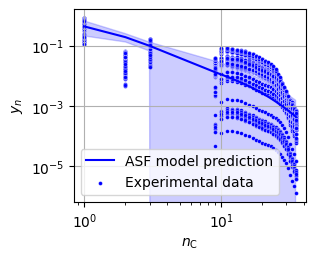

In [100]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=y_n, 
                x="n_C", 
                y="y_n_pred_no_Kc", 
                ax = ax,
                label = 'ASF model prediction',
                color = 'blue',
                errorbar=("sd", 1)
)
sns.scatterplot(
                data=y_n, 
                x="n_C", 
                y="y_n_exp", 
                ax = ax,
                label = 'Experimental data',
                color = 'blue', s = 8
)
plt.grid('both')
plt.ylabel('$y_n$')
plt.xlabel(r'$n_\mathrm{C}$')
plt.yscale('log')
plt.xscale('log')
# plt.ylim(-0.05,1.05)
fig_name = 'ASF_plot_no_K_Cn.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, bbox_inches = 'tight')

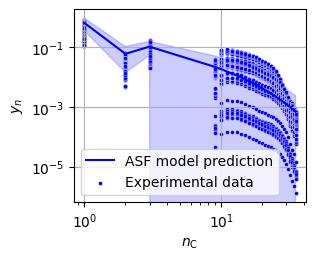

In [101]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.lineplot(
                data=y_n, 
                x="n_C", 
                y="y_n_pred", 
                ax = ax,
                label = 'ASF model prediction',
                color = 'blue',
                errorbar=("sd", 1)
)
sns.scatterplot(
                data=y_n, 
                x="n_C", 
                y="y_n_exp", 
                ax = ax,
                label = 'Experimental data',
                color = 'blue', s = 8
)
plt.grid('both')
plt.ylabel('$y_n$')
plt.xlabel(r'$n_\mathrm{C}$')
plt.yscale('log')
plt.xscale('log')
# plt.ylim(-0.05,1.05)
fig_name = 'ASF_plot.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, bbox_inches = 'tight')

In [102]:
H2_CO_data = data[['F_H2_e_mol_s', 'F_H2_s_mol_s', 'F_CO_e_mol_s', 'F_CO_s_mol_s']]

In [103]:
H2_CO_data.std()/H2_CO_data.mean()

F_H2_e_mol_s    0.194328
F_H2_s_mol_s    0.373479
F_CO_e_mol_s    0.175449
F_CO_s_mol_s    0.280271
dtype: float64